# TUGAS KELOMPOK NLP
Nama:

*   Rizki Dwi Sya'bana Nugraha (10522121)
*   Nur Aisah (10522126)
*   Hilman Fauzi Abdilah (10522034)
*   Sandy Permana (10522013)

**Keyword Extraction**

Dataset : https://github.com/agus235032/sequence/blob/master/33218302_abstrak.csv

Jumlah dataset: 500

Dataset berisi abstrak skripsi berbahasa Indonesia.
Tujuan : mengekstrak kata kunci penting dari abstrak tersebut dan mengelompokkan abstrak berdasarkan topiknya secara otomatis.

**Klasifikasi menggunakan (SVM & Naive Bayes)**



## 0. Install Library

In [ ]:
!pip install pandas requests nltk rake-nltk yake keybert PySastrawi scikit-learn pytextrank -q
!pip install -U spacy -q
!python -m spacy download xx_ent_wiki_sm -q
!pip install matplotlib seaborn wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 35.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 114.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import requests
import re
import nltk
import warnings
warnings.filterwarnings("ignore")

from io import StringIO
from collections import Counter
from string import punctuation

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Sastrawi (Bahasa Indonesia)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Keyword Extraction
from rake_nltk import Rake
import yake
from keybert import KeyBERT
import spacy
import pytextrank

# Classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print("Semua library berhasil diimport")

/usr/local/lib/python3.12/dist-packages
Semua library berhasil diimport


## 2. Load Dataset

In [ ]:
URL = "https://raw.githubusercontent.com/agus235032/sequence/master/33218302_abstrak.csv"

response = requests.get(URL)
df = pd.read_csv(StringIO(response.content.decode("latin1")),
                 sep=";", on_bad_lines="skip")

# Ambil kolom yang relevan
df = df[["No", "Abstract"]].dropna(subset=["Abstract"])
df["Abstract"] = df["Abstract"].astype(str)
df = df.reset_index(drop=True)

print(f"   Dataset berhasil dimuat")
print(f"   Jumlah dokumen : {len(df)}")
print(f"   Kolom          : {df.columns.tolist()}")
print(f"\n   Contoh abstrak #1:")
print(f"   {df['Abstract'].iloc[0][:250]}...")

   Dataset berhasil dimuat
   Jumlah dokumen : 500
   Kolom          : ['No', 'Abstract']

   Contoh abstrak #1:
   Berkembangnya teknologi dan kebutuhan akan informasi menyebabkan bertambah kompleknya informasi yang harus dan bisa diolah, sehingga kebutuhan beberapa jaringan komputer yang lebih dikenal dengan nama internet semakin diperlukan. Berbagai macam tekhn...


## 3. Cleaning & Preprocessing

Pipeline pembersihan:
1. Lowercase
2. Hapus URL (`https://`, `http://`)
3. Hapus angka, tanda baca, karakter non-huruf
4. Normalisasi kata slang/tidak baku
5. Hapus stopwords Bahasa Indonesia (Sastrawi + custom)
6. Hapus kata pendek (≤2 karakter)
7. Stemming — diaktifkan untuk fitur TF-IDF


In [ ]:
# Kamus normalisasi slang
SLANG_DICT = {
    "yg": "yang", "dgn": "dengan", "utk": "untuk", "tsb": "tersebut",
    "dll": "dan lain lain", "dsb": "dan sebagainya", "dpt": "dapat",
    "jg": "juga", "pd": "pada", "kpd": "kepada", "krn": "karena",
    "sdh": "sudah", "blm": "belum", "tdk": "tidak", "tak": "tidak",
    "sbg": "sebagai", "thd": "terhadap", "dlm": "dalam", "dr": "dari",
    "dg": "dengan", "spy": "supaya", "stlh": "setelah", "sblm": "sebelum",
    "tekhnologi": "teknologi",
}

# Stopwords Bahasa Indonesia
sw_factory = StopWordRemoverFactory()
ID_STOPWORDS = set(sw_factory.get_stop_words())
ID_STOPWORDS.update({
    "serta", "agar", "bagi", "oleh", "itu", "ini", "dari", "untuk",
    "yang", "dalam", "dan", "atau", "ke", "di", "dengan", "telah",
    "pada", "juga", "dapat", "akan", "adalah", "sebagai", "secara",
    "sehingga", "tersebut", "merupakan", "antara", "suatu", "lebih",
    "maupun", "ada", "sudah", "belum", "maka", "karena", "namun",
})

# Stemmer Bahasa Indonesia
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def normalize_slang(text):
    return " ".join(SLANG_DICT.get(w, w) for w in text.split())

def clean_text(text, apply_stem=False):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = normalize_slang(text)
    words = [w for w in text.split() if w not in ID_STOPWORDS and len(w) > 2]
    if apply_stem:
        words = [stemmer.stem(w) for w in words]
    return " ".join(words)

df["clean_text"]   = df["Abstract"].apply(lambda x: clean_text(x, apply_stem=False))
df["stemmed_text"] = df["Abstract"].apply(lambda x: clean_text(x, apply_stem=True))

print(" Preprocessing selesai")
print(f"\n   ORIGINAL : {df['Abstract'].iloc[0][:150]}...")
print(f"   CLEANED  : {df['clean_text'].iloc[0][:150]}...")
print(f"   STEMMED  : {df['stemmed_text'].iloc[0][:150]}...")

 Preprocessing selesai

   ORIGINAL : Berkembangnya teknologi dan kebutuhan akan informasi menyebabkan bertambah kompleknya informasi yang harus dan bisa diolah, sehingga kebutuhan beberap...
   CLEANED  : berkembangnya teknologi kebutuhan informasi menyebabkan bertambah kompleknya informasi diolah kebutuhan jaringan komputer dikenal nama internet teknol...
   STEMMED  : kembang teknologi butuh informasi sebab tambah kompleknya informasi olah butuh jaring komputer kenal nama internet teknologi internet word wide web ol...


## 4. EDA (Exploratory Data Analysis)

EDA dilakukan untuk memahami karakteristik dataset sebelum ekstraksi keyword:
- Distribusi panjang abstrak
- Frekuensi kata sebelum & sesudah cleaning
- Word cloud untuk melihat topik dominan


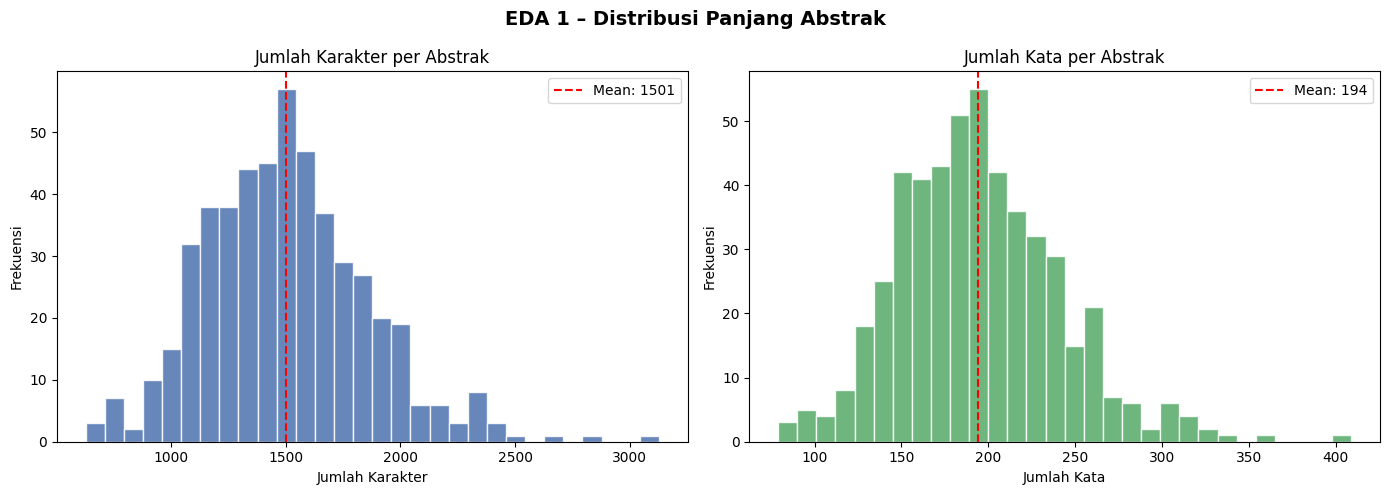

   Jumlah dokumen      : 500
   Rata-rata kata/abstrak : 194
   Min / Max kata      : 79 / 409


In [ ]:
# EDA 1 — Distribusi Panjang Abstrak
df["char_count"] = df["Abstract"].str.len()
df["word_count"] = df["Abstract"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA 1 – Distribusi Panjang Abstrak", fontsize=14, fontweight="bold")

axes[0].hist(df["char_count"], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["char_count"].mean(), color="red", linestyle="--", label=f"Mean: {df['char_count'].mean():.0f}")
axes[0].set_title("Jumlah Karakter per Abstrak")
axes[0].set_xlabel("Jumlah Karakter"); axes[0].set_ylabel("Frekuensi"); axes[0].legend()

axes[1].hist(df["word_count"], bins=30, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(df["word_count"].mean(), color="red", linestyle="--", label=f"Mean: {df['word_count'].mean():.0f}")
axes[1].set_title("Jumlah Kata per Abstrak")
axes[1].set_xlabel("Jumlah Kata"); axes[1].set_ylabel("Frekuensi"); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"   Jumlah dokumen      : {len(df)}")
print(f"   Rata-rata kata/abstrak : {df['word_count'].mean():.0f}")
print(f"   Min / Max kata      : {df['word_count'].min()} / {df['word_count'].max()}")

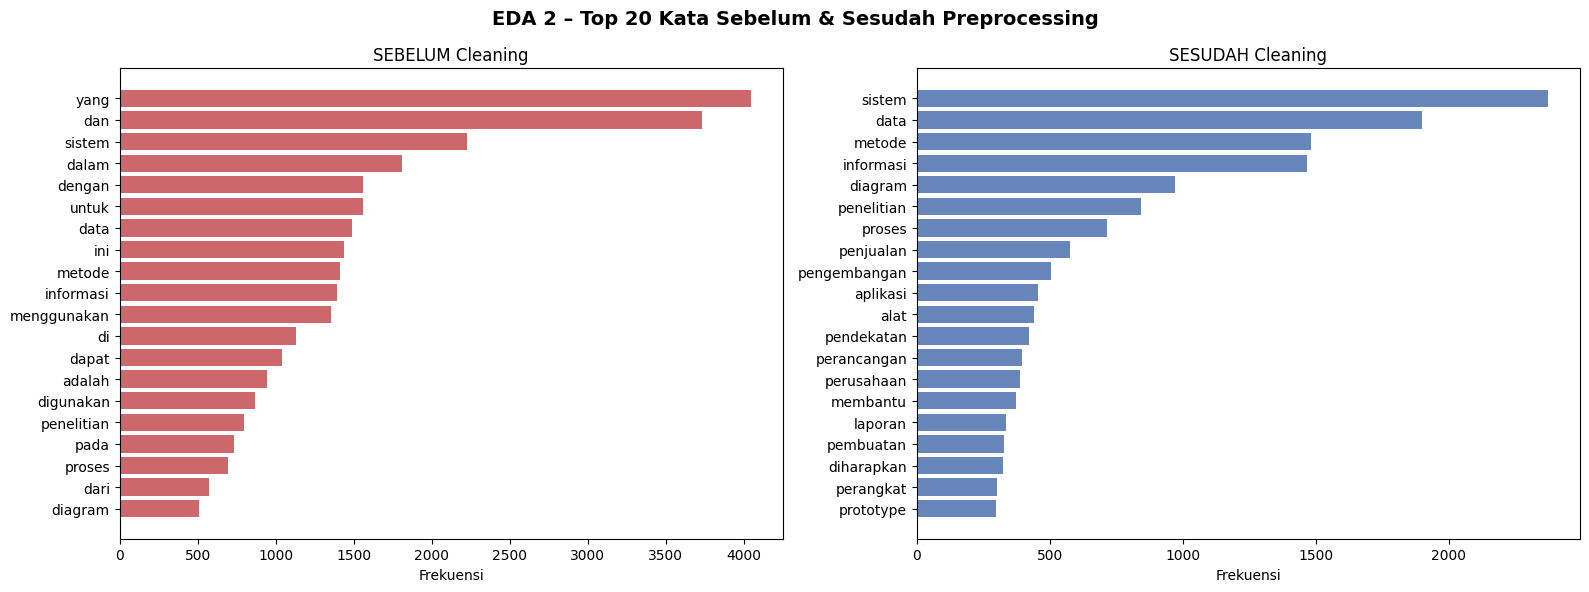

   Vocabulary sebelum : 8,263 kata unik
   Vocabulary sesudah : 5,035 kata unik
   Reduksi            : 39.1%


In [ ]:
# EDA 2 — Frekuensi Kata Sebelum & Sesudah Cleaning
def top_words(series, n=20):
    all_words = " ".join(series).split()
    return Counter(all_words).most_common(n)

top_before = top_words(df["Abstract"].str.lower())
top_after  = top_words(df["clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("EDA 2 – Top 20 Kata Sebelum & Sesudah Preprocessing", fontsize=14, fontweight="bold")

words_b, counts_b = zip(*top_before)
axes[0].barh(words_b[::-1], counts_b[::-1], color="#C44E52", alpha=0.85)
axes[0].set_title("SEBELUM Cleaning"); axes[0].set_xlabel("Frekuensi")

words_a, counts_a = zip(*top_after)
axes[1].barh(words_a[::-1], counts_a[::-1], color="#4C72B0", alpha=0.85)
axes[1].set_title("SESUDAH Cleaning"); axes[1].set_xlabel("Frekuensi")

plt.tight_layout(); plt.show()

vocab_before = len(set(" ".join(df["Abstract"].str.lower()).split()))
vocab_after  = len(set(" ".join(df["clean_text"]).split()))
print(f"   Vocabulary sebelum : {vocab_before:,} kata unik")
print(f"   Vocabulary sesudah : {vocab_after:,} kata unik")
print(f"   Reduksi            : {((vocab_before - vocab_after)/vocab_before*100):.1f}%")

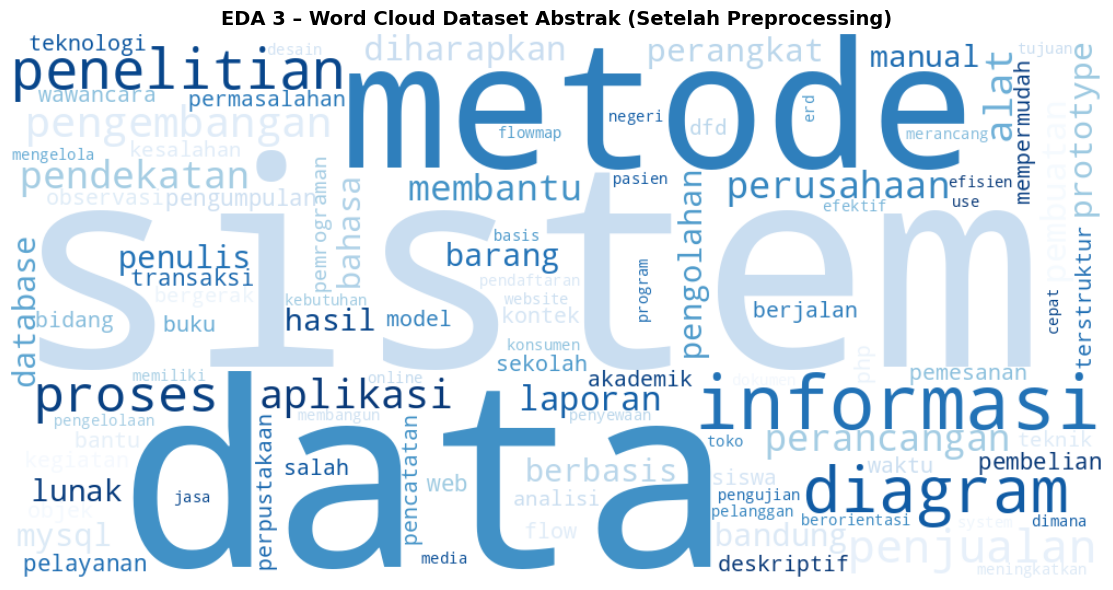

   Insight: Kata dominan mencerminkan topik utama dataset skripsi


In [ ]:
# EDA 3 — Word Cloud
all_clean = " ".join(df["clean_text"])
wc = WordCloud(width=1000, height=500, background_color="white",
               colormap="Blues", max_words=100, collocations=False).generate(all_clean)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("EDA 3 – Word Cloud Dataset Abstrak (Setelah Preprocessing)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("   Insight: Kata dominan mencerminkan topik utama dataset skripsi")

## 5. Keyword Extraction — 5 Metode

Setiap metode dijalankan terhadap **seluruh 500 abstrak**.  
Hasilnya disimpan sebagai kolom baru di dataframe → menjadi dasar labeling dan evaluasi.

| Metode | Input | Cara Kerja |
|--------|-------|------------|
| **TextRank** | Teks asli | Graf kalimat berbasis kesamaan kalimat |
| **KeyBERT** | Teks clean | Cosine similarity embedding BERT |
| **RAKE** | Teks asli | Co-occurrence kata non-stopword |
| **YAKE** | Teks clean | Statistik kemunculan lokal |
| **spaCy POS** | Teks clean | Frekuensi NOUN/PROPN/ADJ |


### 5A. TextRank (PyTextRank + spaCy)

In [ ]:
print("Memuat model spaCy multilingual...")

nlp_tr = spacy.load("xx_ent_wiki_sm")

#  Tambahkan sentencizer, kemudian textrank
if "sentencizer" not in nlp_tr.pipe_names:
    nlp_tr.add_pipe("sentencizer")
if "textrank" not in nlp_tr.pipe_names:
    nlp_tr.add_pipe("textrank")

def extract_textrank(text, top_n=5):
    try:
        doc = nlp_tr(text[:1500])
        phrases = doc._.phrases[:top_n]
        return [p.text for p in phrases]
    except Exception:
        return []

# Demo pada abstrak pertama
sample_raw  = df["Abstract"].iloc[0]
kw_tr_demo = extract_textrank(sample_raw)
print("\n[DEMO — Abstrak #1]")
print("Keywords (TextRank):", ", ".join(kw_tr_demo))

# Jalankan untuk semua dokumen
print("\nMengekstrak TextRank untuk semua dokumen...")
df["kw_textrank"] = df["Abstract"].apply(lambda x: extract_textrank(x))
print(f" TextRank selesai — {len(df)} dokumen")
print("\nContoh 3 baris pertama:")
for i in range(3):
    print(f"  [{i+1}] {df['kw_textrank'].iloc[i]}")

Memuat model spaCy multilingual...

[DEMO — Abstrak #1]
Keywords (TextRank): Berkembangnya, OOAD, Object Oriented Analysis and Design, PHP, SAMARINDA

Mengekstrak TextRank untuk semua dokumen...
 TextRank selesai — 500 dokumen

Contoh 3 baris pertama:
  [1] ['Berkembangnya', 'OOAD', 'Object Oriented Analysis and Design', 'PHP', 'SAMARINDA']
  [2] ['Bidang Administrasi', 'Koperasi Karyawan PT', 'PT', 'Pengembangan Sistem Informasi Aplikasi', 'Pindad Bandung']
  [3] ['Ada', 'Dalam Penulisan', 'SMUN 1 Ciamis', 'dalam memperoleh', 'itu']


### 5B. KeyBERT (IndoBERT / Multilingual BERT)

In [ ]:
# KeyBERT menggunakan embedding BERT untuk mengukur kesamaan semantik
# antara frasa kandidat dan keseluruhan teks
print("Memuat model KeyBERT (IndoBERT)...")

try:
    kw_model = KeyBERT("indobenchmark/indobert-base-p1")
    model_name = "IndoBERT"
except Exception:
    kw_model = KeyBERT("distiluse-base-multilingual-cased-v2")
    model_name = "multilingual DistilUSE"
print(f"Model: {model_name}")

def extract_keybert(text, top_n=5):
    try:
        kws = kw_model.extract_keywords(
            text,
            keyphrase_ngram_range=(1, 3),
            stop_words=list(ID_STOPWORDS),
            use_mmr=True,
            diversity=0.5,
            top_n=top_n
        )
        return [kw for kw, _ in kws]
    except Exception:
        return []

# Demo
kw_bert_demo = extract_keybert(df["clean_text"].iloc[0])
print("\n[DEMO — Abstrak #1]")
print("Keywords (KeyBERT):", ", ".join(kw_bert_demo))

print("\nMengekstrak KeyBERT untuk semua dokumen (proses lambat ~beberapa menit)...")
df["kw_keybert"] = df["clean_text"].apply(lambda x: extract_keybert(x))
print(f" KeyBERT selesai — {len(df)} dokumen")
print("\nContoh 3 baris pertama:")
for i in range(3):
    print(f"  [{i+1}] {df['kw_keybert'].iloc[i]}")

Memuat model KeyBERT (IndoBERT)...


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model: IndoBERT

[DEMO — Abstrak #1]
Keywords (KeyBERT): memanfaatkan teknologi web, diharapakan gambaran pengembangan, mudah updating maintence, dicarilah solusi pemahasannya, stmik samarinda perguruan

Mengekstrak KeyBERT untuk semua dokumen (proses lambat ~beberapa menit)...
 KeyBERT selesai — 500 dokumen

Contoh 3 baris pertama:
  [1] ['memanfaatkan teknologi web', 'diharapakan gambaran pengembangan', 'mudah updating maintence', 'dicarilah solusi pemahasannya', 'stmik samarinda perguruan']
  [2] ['sistem informasi proses', 'aplikasi tabungan siaga', 'bandung koperasi instansi', 'usipa kopkar pindad', 'kendala kendala dihadapi']
  [3] ['pengolahan keuangan sekolah', 'akurat penghitungan nilainnya', 'skripsi penulis menganalisis', 'kesalahan penulisan diminimalis', 'bertugas menyelenggarakan kegiatan']


### 5C. RAKE (Rapid Automatic Keyword Extraction)

In [ ]:
# RAKE bekerja dengan memecah teks menggunakan stopword sebagai delimiter.
# Jika teks sudah dihapus stopword-nya → tidak ada delimiter → 1 frasa raksasa.

def extract_rake(text, top_n=5):
    try:
        rake = Rake(stopwords=list(ID_STOPWORDS), punctuations=punctuation)
        rake.extract_keywords_from_text(text)  # ← teks ASLI
        ranked = rake.get_ranked_phrases()
        # Filter frasa yang terlalu panjang (>6 kata) agar bermakna
        ranked = [p for p in ranked if len(p.split()) <= 6]
        return ranked[:top_n]
    except Exception:
        return []

# Demo
kw_rake_demo = extract_rake(df["Abstract"].iloc[0])
print("[DEMO — Abstrak #1]")
print("Keywords (RAKE):", ", ".join(kw_rake_demo))

# Semua dokumen
print("\nMengekstrak RAKE untuk semua dokumen...")
df["kw_rake"] = df["Abstract"].apply(lambda x: extract_rake(x))
print(f" RAKE selesai — {len(df)} dokumen")
print("\nContoh 3 baris pertama:")
for i in range(3):
    print(f"  [{i+1}] {df['kw_rake'].iloc[i]}")

[DEMO — Abstrak #1]
Keywords (RAKE): object oriented analysis and design, informasi menyebabkan bertambah kompleknya informasi, memanfaatkan teknologi web menyebabkan web, pengembangan website stmik samarinda, memanfaatkan teknologi informasi

Mengekstrak RAKE untuk semua dokumen...
 RAKE selesai — 500 dokumen

Contoh 3 baris pertama:
  [1] ['object oriented analysis and design', 'informasi menyebabkan bertambah kompleknya informasi', 'memanfaatkan teknologi web menyebabkan web', 'pengembangan website stmik samarinda', 'memanfaatkan teknologi informasi']
  [2] ['pengembangan sistem informasi aplikasi tabungan siaga', 'unit usaha simpan pinjam', 'membantu proses tabungan siaga', 'proses pembuatan kwitansi tabungan', 'bidang pengolahan data keuangan']
  [3] ['penulis menganalisis pengolahan data keuangan sekolah', 'proses pengolahan data dimana data', 'proses pengolahan keuangan sekolah', 'tujuan mencerdaskan kehidupan bangsa', 'bertugas menyelenggarakan kegiatan pendidikan']


### 5D. YAKE (Yet Another Keyword Extractor)

In [ ]:
# YAKE menggunakan statistik lokal (posisi, frekuensi, dispersi)
# Skor YAKE: makin KECIL = makin relevan (berbeda dengan metode lain)

yake_extractor = yake.KeywordExtractor(
    lan="id", n=3, dedupLim=0.7, dedupFunc="seqm", top=10
)

def extract_yake(text, top_n=5):
    try:
        kws = yake_extractor.extract_keywords(text)
        return [kw for kw, _ in kws[:top_n]]
    except Exception:
        return []

# Demo
kw_yake_demo = extract_yake(df["clean_text"].iloc[0])
print("[DEMO — Abstrak #1]")
print("Keywords (YAKE):", ", ".join(kw_yake_demo))

# Semua dokumen
print("\nMengekstrak YAKE untuk semua dokumen...")
df["kw_yake"] = df["clean_text"].apply(lambda x: extract_yake(x))
print(f" YAKE selesai — {len(df)} dokumen")
print("\nContoh 3 baris pertama:")
for i in range(3):
    print(f"  [{i+1}] {df['kw_yake'].iloc[i]}")

[DEMO — Abstrak #1]
Keywords (YAKE): website stmik samarinda, stmik samarinda perguruan, stmik samarinda membangun, samarinda perguruan tinggi, interaksi mahasiswa stmik

Mengekstrak YAKE untuk semua dokumen...
 YAKE selesai — 500 dokumen

Contoh 3 baris pertama:
  [1] ['website stmik samarinda', 'stmik samarinda perguruan', 'stmik samarinda membangun', 'samarinda perguruan tinggi', 'interaksi mahasiswa stmik']
  [2] ['proses tabungan siaga', 'unit usaha simpan', 'usaha simpan pinjam', 'pengolahan data keuangan', 'data keuangan kesemuanya']
  [3] ['pengolahan data keuangan', 'proses pengolahan data', 'akurat penghitungan nilainnya', 'pemerintah bertugas menyelenggarakan', 'bertugas menyelenggarakan kegiatan']


### 5E. spaCy POS Tagging


In [ ]:
# Pendekatan alternatif spaCy POS untuk Bahasa Indonesia:
# Karena xx_ent_wiki_sm tidak memiliki POS tagger,
# kita gunakan heuristik: ambil kata dengan panjang ≥4 karakter
# yang sering muncul dan bukan stopword → mirip dengan NOUN/content word

nlp_pos = spacy.load("xx_ent_wiki_sm")

def extract_spacy_pos(text, top_n=5):
    try:
        # Gunakan token yang panjang dan bukan stopword sebagai proxy NOUN/PROPN
        doc = nlp_pos(text.lower()[:1000])
        candidates = []
        for token in doc:
            word = token.text
            if (len(word) >= 4
                    and word not in ID_STOPWORDS
                    and word not in punctuation
                    and word.isalpha()):
                candidates.append(word)
        # Ambil yang paling sering muncul
        most_common = Counter(candidates).most_common(top_n)
        return [word for word, _ in most_common]
    except Exception:
        return []

# Demo
kw_spacy_demo = extract_spacy_pos(df["clean_text"].iloc[0])
print("[DEMO — Abstrak #1]")
print("Keywords (spaCy token freq):", ", ".join(kw_spacy_demo))

# Semua dokumen
print("\nMengekstrak spaCy POS untuk semua dokumen...")
df["kw_spacy"] = df["clean_text"].apply(lambda x: extract_spacy_pos(x))
print(f" spaCy POS selesai — {len(df)} dokumen")
print("\nContoh 3 baris pertama:")
for i in range(3):
    print(f"  [{i+1}] {df['kw_spacy'].iloc[i]}")

[DEMO — Abstrak #1]
Keywords (spaCy token freq): informasi, stmik, website, teknologi, samarinda

Mengekstrak spaCy POS untuk semua dokumen...
 spaCy POS selesai — 500 dokumen

Contoh 3 baris pertama:
  [1] ['informasi', 'stmik', 'website', 'teknologi', 'samarinda']
  [2] ['sistem', 'informasi', 'tabungan', 'proses', 'siaga']
  [3] ['pengolahan', 'data', 'proses', 'keuangan', 'sekolah']


### 5F. Rekap Keyword Semua Metode (per Abstrak)

In [ ]:
# Rekap output KE untuk semua abstrak
print("=" * 80)
print("REKAP KEYWORD EXTRACTION — SEMUA METODE")
print("=" * 80)

# Tampilkan untuk 5 abstrak pertama
for i in range(min(5, len(df))):
    print(f"\n📄 Abstrak #{i+1}:")
    print(f"   Teks    : {df['Abstract'].iloc[i][:100]}...")
    print(f"   TextRank: {', '.join(df['kw_textrank'].iloc[i]) or '(kosong)'}")
    print(f"   KeyBERT : {', '.join(df['kw_keybert'].iloc[i]) or '(kosong)'}")
    print(f"   RAKE    : {', '.join(df['kw_rake'].iloc[i]) or '(kosong)'}")
    print(f"   YAKE    : {', '.join(df['kw_yake'].iloc[i]) or '(kosong)'}")
    print(f"   spaCy   : {', '.join(df['kw_spacy'].iloc[i]) or '(kosong)'}")

print(f"\n Total dokumen dengan KE: {len(df)}")

REKAP KEYWORD EXTRACTION — SEMUA METODE

📄 Abstrak #1:
   Teks    : Berkembangnya teknologi dan kebutuhan akan informasi menyebabkan bertambah kompleknya informasi yang...
   TextRank: Berkembangnya, OOAD, Object Oriented Analysis and Design, PHP, SAMARINDA
   KeyBERT : memanfaatkan teknologi web, diharapakan gambaran pengembangan, mudah updating maintence, dicarilah solusi pemahasannya, stmik samarinda perguruan
   RAKE    : object oriented analysis and design, informasi menyebabkan bertambah kompleknya informasi, memanfaatkan teknologi web menyebabkan web, pengembangan website stmik samarinda, memanfaatkan teknologi informasi
   YAKE    : website stmik samarinda, stmik samarinda perguruan, stmik samarinda membangun, samarinda perguruan tinggi, interaksi mahasiswa stmik
   spaCy   : informasi, stmik, website, teknologi, samarinda

📄 Abstrak #2:
   Teks    : Pengembangan Sistem Informasi Aplikasi Tabungan Siaga pada Unit Usaha Simpan Pinjam di Koperasi Kary...
   TextRank: Bidang Admin

## 6. Labeling Dokumen (Berbasis Keyword YAKE)

Karena dataset tidak memiliki label manual, label dibuat dari keyword YAKE  
dengan mencocokkan keyword ke domain topik yang sudah didefinisikan.

Ini lebih interpretatif daripada clustering KMeans karena:
- Label bisa dibaca dan dimengerti manusianya
- Keyword dari KE langsung digunakan sebagai dasar labeling
- Hasilnya menghubungkan KE → klasifikasi secara eksplisit


In [ ]:
# Domain keyword yang didefinisikan manual berdasarkan topik skripsi IT
DOMAIN_KEYWORDS = {
    "sistem_informasi": ["sistem", "informasi", "data", "database", "aplikasi", "website"],
    "jaringan_komputer": ["jaringan", "network", "internet", "server", "protokol", "wifi", "router"],
    "mobile_app":        ["android", "mobile", "smartphone", "app", "ios", "flutter", "kotlin"],
    "kecerdasan_buatan": ["prediksi", "klasifikasi", "neural", "machine", "learning", "clustering", "naive"],
}

def assign_label(keywords_list):
    """Cocokkan keyword ke domain — ambil domain dengan poin terbanyak."""
    if not keywords_list:
        return "sistem_informasi"  # default
    all_kw = " ".join(keywords_list).lower()
    scores = {domain: 0 for domain in DOMAIN_KEYWORDS}
    for domain, domain_kws in DOMAIN_KEYWORDS.items():
        for kw in domain_kws:
            if kw in all_kw:
                scores[domain] += 1
    best = max(scores, key=scores.get)
    # Jika tidak ada cocok sama sekali → fallback ke sistem_informasi
    return best if scores[best] > 0 else "sistem_informasi"

# Gunakan keyword dari YAKE sebagai dasar labeling
# (bisa diganti kw_textrank, kw_keybert, dll.)
df["label"] = df["kw_yake"].apply(assign_label)

print(" Labeling selesai (berbasis keyword YAKE)")
print("\nDistribusi label:")
label_counts = df["label"].value_counts()
for label, count in label_counts.items():
    print(f"  {label:<25} : {count} dokumen ({count/len(df)*100:.1f}%)")

 Labeling selesai (berbasis keyword YAKE)

Distribusi label:
  sistem_informasi          : 489 dokumen (97.8%)
  mobile_app                : 6 dokumen (1.2%)
  jaringan_komputer         : 4 dokumen (0.8%)
  kecerdasan_buatan         : 1 dokumen (0.2%)


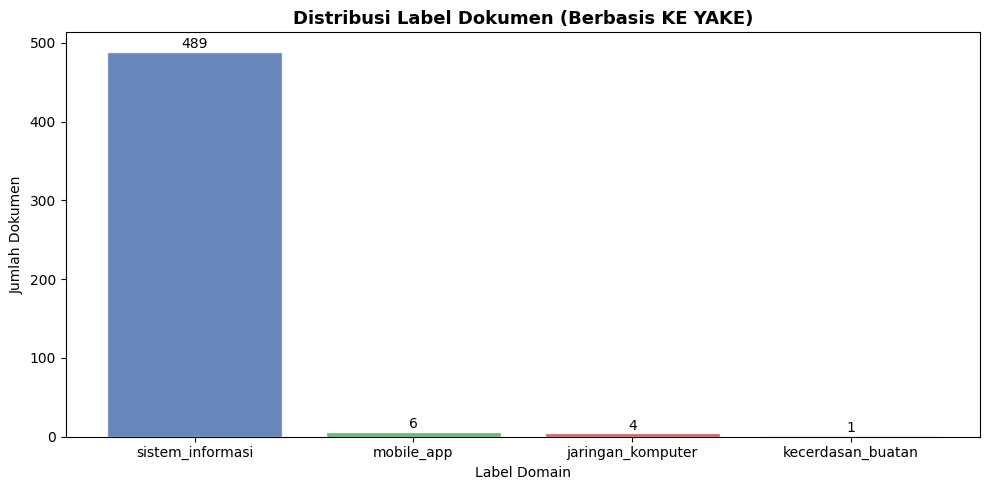

In [ ]:
# Visualisasi distribusi label
fig, ax = plt.subplots(figsize=(10, 5))
colors_label = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
bars = ax.bar(label_counts.index, label_counts.values,
              color=colors_label[:len(label_counts)], alpha=0.85, edgecolor="white")
ax.set_title("Distribusi Label Dokumen (Berbasis KE YAKE)", fontsize=13, fontweight="bold")
ax.set_xlabel("Label Domain"); ax.set_ylabel("Jumlah Dokumen")
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

## 7. Feature Extraction — TF-IDF

TF-IDF digunakan sebagai representasi numerik teks untuk input ke model klasifikasi.  
Input: `stemmed_text` (sudah dibersihkan + di-stem).


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X = vectorizer.fit_transform(df["stemmed_text"])

le = LabelEncoder()
y  = le.fit_transform(df["label"])

print(f"   TF-IDF selesai")
print(f"   Shape fitur    : {X.shape}")
print(f"   Jumlah label   : {len(le.classes_)}")
print(f"   Kelas          : {le.classes_}")

   TF-IDF selesai
   Shape fitur    : (500, 500)
   Jumlah label   : 4
   Kelas          : ['jaringan_komputer' 'kecerdasan_buatan' 'mobile_app' 'sistem_informasi']


## 8. Split Dataset (Train / Test)

In [ ]:
from sklearn.model_selection import train_test_split

# Cek distribusi label dulu
print("Distribusi label:")
print(df["label"].value_counts())

# Hapus label yang jumlahnya < 2 agar bisa di-stratify
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df_filtered = df[df["label"].isin(valid_labels)].copy()

print(f"\nDokumen sebelum filter : {len(df)}")
print(f"Dokumen setelah filter : {len(df_filtered)}")

# Re-vectorize dan re-encode dengan data yang sudah difilter
X = vectorizer.fit_transform(df_filtered["stemmed_text"])
le = LabelEncoder()
y  = le.fit_transform(df_filtered["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Split selesai")
print(f"   Train : {X_train.shape[0]} dokumen")
print(f"   Test  : {X_test.shape[0]} dokumen")
print(f"   Kelas : {le.classes_}")

Distribusi label:
label
sistem_informasi     489
mobile_app             6
jaringan_komputer      4
kecerdasan_buatan      1
Name: count, dtype: int64

Dokumen sebelum filter : 500
Dokumen setelah filter : 499

 Split selesai
   Train : 399 dokumen
   Test  : 100 dokumen
   Kelas : ['jaringan_komputer' 'mobile_app' 'sistem_informasi']


## 9. Modeling — SVM & Naive Bayes

Model dilatih menggunakan fitur TF-IDF dari teks yang sudah dibersihkan.  
Label berasal dari keyword extraction (YAKE) → **KE terhubung ke modeling**.


In [ ]:
# ── Support Vector Machine (SVM) ──
print("=" * 55)
print("   Model: Support Vector Machine (SVM) — Linear Kernel")
print("=" * 55)

svm = SVC(kernel="linear", C=1.0, random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(f"\n  Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred_svm,
                             target_names=le.classes_, zero_division=0))

   Model: Support Vector Machine (SVM) — Linear Kernel

  Accuracy : 0.9800

  Classification Report:
                   precision    recall  f1-score   support

jaringan_komputer       0.00      0.00      0.00         1
       mobile_app       0.00      0.00      0.00         1
 sistem_informasi       0.98      1.00      0.99        98

         accuracy                           0.98       100
        macro avg       0.33      0.33      0.33       100
     weighted avg       0.96      0.98      0.97       100



In [ ]:
# ── Naive Bayes (Multinomial NB) ──
print("=" * 55)
print("   Model: Multinomial Naive Bayes (NB)")
print("=" * 55)

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(f"\n  Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred_nb,
                             target_names=le.classes_, zero_division=0))

   Model: Multinomial Naive Bayes (NB)

  Accuracy : 0.9800

  Classification Report:
                   precision    recall  f1-score   support

jaringan_komputer       0.00      0.00      0.00         1
       mobile_app       0.00      0.00      0.00         1
 sistem_informasi       0.98      1.00      0.99        98

         accuracy                           0.98       100
        macro avg       0.33      0.33      0.33       100
     weighted avg       0.96      0.98      0.97       100



## 10. Perbandingan Model & Output per Abstrak

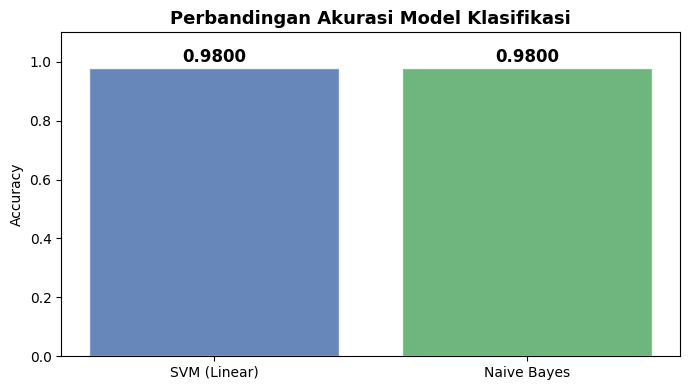

  SVM Accuracy  : 0.9800
  NB  Accuracy  : 0.9800
  Model terbaik : SVM


In [ ]:
# Perbandingan akurasi
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_nb  = accuracy_score(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["SVM (Linear)", "Naive Bayes"], [acc_svm, acc_nb],
       color=["#4C72B0", "#55A868"], alpha=0.85, edgecolor="white")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Perbandingan Akurasi Model Klasifikasi", fontsize=13, fontweight="bold")
for i, acc in enumerate([acc_svm, acc_nb]):
    ax.text(i, acc + 0.02, f"{acc:.4f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"  SVM Accuracy  : {acc_svm:.4f}")
print(f"  NB  Accuracy  : {acc_nb:.4f}")
print(f"  Model terbaik : {'SVM' if acc_svm >= acc_nb else 'Naive Bayes'}")

In [ ]:
# Output KE + prediksi label per abstrak (10 baris pertama)
print("OUTPUT KEYWORD EXTRACTION + PREDIKSI LABEL — 10 Abstrak Pertama")
print("=" * 90)

# Predictions were made on X which corresponds to df_filtered (499 rows).
# To assign them back to the original df (500 rows), we need to align by index.

# Predict labels for the filtered data (X has 499 samples from df_filtered)
y_pred_for_filtered_df = svm.predict(X)

# Convert numerical predictions back to original label names
predicted_labels_filtered_df = le.inverse_transform(y_pred_for_filtered_df)

# Create a temporary Series for the predicted labels, with the index of df_filtered
predicted_labels_series = pd.Series(predicted_labels_filtered_df, index=df_filtered.index)

# Add a 'predicted_label' column to the original df, initializing with a placeholder
# for the row that was dropped. (Original df has 500 rows, df_filtered has 499).
df["predicted_label"] = "Not Classified" # Initialize with a placeholder

# Update the 'predicted_label' column in the original df using .loc
# This aligns the predictions with the correct rows in df.
df.loc[df_filtered.index, "predicted_label"] = predicted_labels_series

for i in range(min(10, len(df))):
    print(f"\n Abstrak #{i+1}:")
    print(f"   Teks        : {df['Abstract'].iloc[i][:90]}...")
    print(f"   YAKE        : {', '.join(df['kw_yake'].iloc[i]) or '-'}")
    print(f"   TextRank    : {', '.join(df['kw_textrank'].iloc[i]) or '-'}")
    print(f"   KeyBERT     : {', '.join(df['kw_keybert'].iloc[i]) or '-'}")
    print(f"   RAKE        : {', '.join(df['kw_rake'].iloc[i]) or '-'}")
    print(f"   spaCy       : {', '.join(df['kw_spacy'].iloc[i]) or '-'}")
    print(f"   Label Asli  : {df['label'].iloc[i]}")
    print(f"   Prediksi SVM: {df['predicted_label'].iloc[i]}")
    print(f"   {' Benar' if df['label'].iloc[i] == df['predicted_label'].iloc[i] else '❌ Salah'}")

OUTPUT KEYWORD EXTRACTION + PREDIKSI LABEL — 10 Abstrak Pertama

 Abstrak #1:
   Teks        : Berkembangnya teknologi dan kebutuhan akan informasi menyebabkan bertambah kompleknya info...
   YAKE        : website stmik samarinda, stmik samarinda perguruan, stmik samarinda membangun, samarinda perguruan tinggi, interaksi mahasiswa stmik
   TextRank    : Berkembangnya, OOAD, Object Oriented Analysis and Design, PHP, SAMARINDA
   KeyBERT     : memanfaatkan teknologi web, diharapakan gambaran pengembangan, mudah updating maintence, dicarilah solusi pemahasannya, stmik samarinda perguruan
   RAKE        : object oriented analysis and design, informasi menyebabkan bertambah kompleknya informasi, memanfaatkan teknologi web menyebabkan web, pengembangan website stmik samarinda, memanfaatkan teknologi informasi
   spaCy       : informasi, stmik, website, teknologi, samarinda
   Label Asli  : sistem_informasi
   Prediksi SVM: sistem_informasi
    Benar

 Abstrak #2:
   Teks        : Pengembanga

## 11. Ringkasan Akhir

In [ ]:
print("RINGKASAN AKHIR")
print("=" * 65)
print(f"  Jumlah dokumen        : {len(df)}")
print(f"  Metode KE yang dipakai:")
print(f"    1. TextRank  — graf kesamaan kalimat (spaCy multilingual)")
print(f"    2. KeyBERT   — embedding BERT (IndoBERT/multilingual)")
print(f"    3. RAKE      — co-occurrence kata, input teks ASLI")
print(f"    4. YAKE      — statistik lokal Bahasa Indonesia")
print(f"    5. spaCy POS — frekuensi token konten (proxy NOUN/PROPN)")
print(f"  Labeling              : Berbasis keyword YAKE → domain IT")
print(f"  Fitur klasifikasi     : TF-IDF (max 500 fitur, bigram)")

print(f"  Model 1 — SVM         : Accuracy = {acc_svm:.4f}")
print(f"  Model 2 — Naive Bayes : Accuracy = {acc_nb:.4f}")
print(f"  Model terbaik         : {'SVM' if acc_svm >= acc_nb else 'Naive Bayes'}")
print()
print("  Alur ringkas:")
print("  Dataset → Cleaning → EDA → KE (5 metode, 500 dok)")
print("  → Labeling (YAKE keyword) → TF-IDF → SVM / NB → Evaluasi")

RINGKASAN AKHIR
  Jumlah dokumen        : 500
  Metode KE yang dipakai:
    1. TextRank  — graf kesamaan kalimat (spaCy multilingual)
    2. KeyBERT   — embedding BERT (IndoBERT/multilingual)
    3. RAKE      — co-occurrence kata, input teks ASLI
    4. YAKE      — statistik lokal Bahasa Indonesia
    5. spaCy POS — frekuensi token konten (proxy NOUN/PROPN)
  Labeling              : Berbasis keyword YAKE → domain IT
  Fitur klasifikasi     : TF-IDF (max 500 fitur, bigram)
  Model 1 — SVM         : Accuracy = 0.9800
  Model 2 — Naive Bayes : Accuracy = 0.9800
  Model terbaik         : SVM

  Alur ringkas:
  Dataset → Cleaning → EDA → KE (5 metode, 500 dok)
  → Labeling (YAKE keyword) → TF-IDF → SVM / NB → Evaluasi
